Running ICA Analysis...


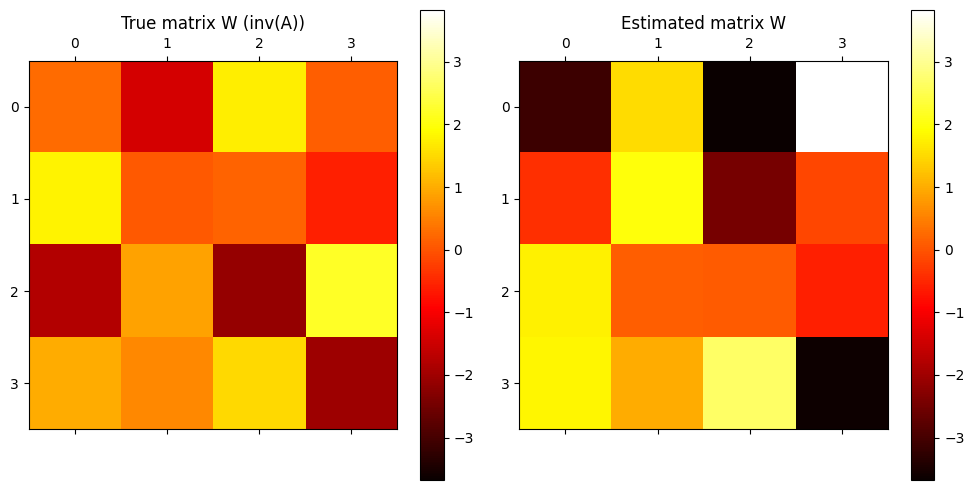

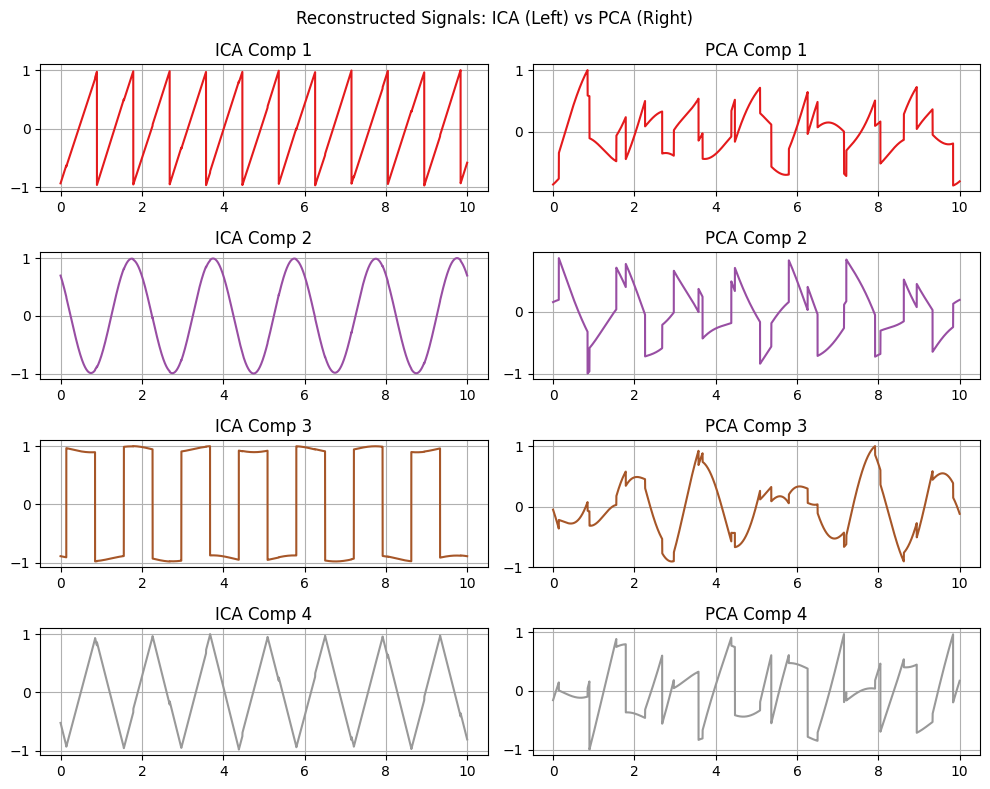

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA, PCA
from matplotlib.pyplot import cm

class BlindSourceSeparator:
    def __init__(self, n_samples, n_signals, seed):
        """
        Class to handle Laboratory 6 Part 2: Artificial ICA.
        Refactored from fastica_artificial.py maintaining original logic.
        """
        self.N = n_samples
        self.N_signals = n_signals
        self.seed = seed
        np.random.seed(self.seed) # set the seed to reproduce the experiment
        
        self.S = None    # True Sources
        self.A = None    # True Mixing Matrix
        self.Y = None    # Mixed Signals
        self.W_true = None # True Unmixing Matrix (Inverse of A)
        
        # Results
        self.XhatICA = None
        self.Ahat = None
        self.What = None
        self.XhatPCA = None
        self.time = None

    def generate_data(self, use_gaussian=False):
        """
        Generate the signals.
        Original logic: Sin, Square, Sawtooth, Triangular (or Gaussian).
        """
        # generate the time axis (seconds)
        t = np.linspace(0, 10, self.N)
        self.time = t
        
        # Resizing for matrix operations as in original script
        # t.resize(1, self.N) # Not strictly necessary if we use 1D array logic properly, keeping it simple
        
        freq1 = 0.5 # main frequency (Hz)
        freq2 = freq1 * np.sqrt(2)
        freq3 = freq1 * np.sqrt(5)
        
        # Signal 1: sinusoidal signal
        x1 = np.sin(2 * np.pi * freq1 * t - np.pi/4)
        
        # Signal 2: square wave
        x2 = np.sign(np.sin(2 * np.pi * freq2 * t - np.pi/5))
        
        # Signal 3: saw tooth signal
        x3 = signal.sawtooth(2 * np.pi * freq3 * t)
        
        # Signal 4: 
        if use_gaussian:
            # if you want to see what happens with signals having Gaussian pdf
            x4 = np.random.randn(self.N)
        else:
            # triangular signal (obtained from cumulative sum of square wave)
            x4 = np.cumsum(x2)
            # Normalize as in original
            x4 = (x4 - x4.mean()) / x4.std()
            x4 = x4 / x4.max()
            
        # Stack signals
        self.S = np.c_[x1, x2, x3, x4]
        
        # Mixing matrix
        # A = np.random.rand(self.N_signals, self.N_signals)
        # To match original script exact shape expectation:
        self.A = np.random.rand(self.N_signals, self.N_signals)
        
        # Generate observations
        # Y = S * A^T (standard matrix mult)
        self.Y = np.dot(self.S, self.A.T)
        
        # True unmixing matrix (for comparison)
        self.W_true = np.linalg.inv(self.A) # Note: FastICA estimates W such that W*A = P*D

    def run_fastica(self):
        """Run FastICA algorithm."""
        # ICA
        # algorithm="deflation" is specified in original
        ica = FastICA(n_components=self.N_signals, algorithm="deflation", whiten="unit-variance", random_state=self.seed)
        
        # Reconstruct indep signals from observations
        self.XhatICA = ica.fit_transform(self.Y)
        
        self.Ahat = ica.mixing_  # estimated A
        self.What = ica.components_ # estimated matrix W: Xhat=np.dot(Y,ica.components_.T)

    def run_pca(self):
        """Use also PCA."""
        pca = PCA(n_components=self.N_signals)
        # Reconstruct signals based on orthogonal components
        self.XhatPCA = pca.fit_transform(self.Y)

    def plot_matrices_comparison(self):
        """
        Plot True matrix W vs Estimated matrix W.
        Original logic: Heatmap with shared vmin/vmax.
        """
        # Note: FastICA recovers W up to permutation and scaling. 
        # Direct comparison is tricky, but we follow the original script's visualization.
        
        # Note on dimensions:
        # Original A was (4,4). Original W_true is inv(A).
        # sklearn FastICA components_ is (n_components, n_features).
        
        vm1 = self.W_true.min()
        VM1 = self.W_true.max()
        vm2 = self.What.min()
        VM2 = self.What.max()
        vm = np.min([vm1, vm2])
        VM = np.max([VM1, VM2])
        
        plt.figure(figsize=(10, 5))
        
        plt.subplot(1, 2, 1)
        # Note: W in original might be defined differently. 
        # Here we assume W_true corresponds to the unmixing process.
        plt.matshow(self.W_true, fignum=0, vmin=vm, vmax=VM, cmap='hot')
        plt.colorbar()
        plt.title('True matrix W (inv(A))')
        
        plt.subplot(1, 2, 2)
        plt.matshow(self.What, fignum=0, vmin=vm, vmax=VM, cmap='hot')
        plt.colorbar()
        plt.title('Estimated matrix W')
        plt.tight_layout()

    def plot_signals(self):
        """Plot the results: ICA vs PCA."""
        # Using a colormap as in original
        color_iter = iter(cm.Set1(np.linspace(0, 1, self.N_signals)))
        
        plt.figure(figsize=(10, 8))
        plt.suptitle("Reconstructed Signals: ICA (Left) vs PCA (Right)")
        
        for n in range(self.N_signals):
            c = next(color_iter)
            
            # ICA Subplots
            plt.subplot(self.N_signals, 2, 2*n + 1)
            # Normalize for plotting as in original
            sig_ica = self.XhatICA[:, n]
            plt.plot(self.time, sig_ica / np.max(np.abs(sig_ica)), color=c)
            plt.title(f'ICA Comp {n+1}')
            plt.grid()
            
            # PCA Subplots
            plt.subplot(self.N_signals, 2, 2*n + 2)
            sig_pca = self.XhatPCA[:, n]
            plt.plot(self.time, sig_pca / np.max(np.abs(sig_pca)), color=c)
            plt.title(f'PCA Comp {n+1}')
            plt.grid()
            
        plt.tight_layout()

if __name__ == "__main__":
    plt.close('all')
    
    # 1. Standard Case
    print("Running ICA Analysis...")
    separator = BlindSourceSeparator(n_samples=10000, n_signals=4, seed=360457)
    separator.generate_data(use_gaussian=False)
    separator.run_fastica()
    separator.run_pca()
    
    separator.plot_matrices_comparison()
    separator.plot_signals()
    
    plt.show()